In [1]:
import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../../dmri/utils/pyloric.mplstyle")


In [2]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated5_b3s_2_4_6_128")
graphdef, params,  state = nnx.split(model, nnx.Param,  ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, state)
sim_type = model.tokenizer.simulator
mask_prior = sim_type.create_mask_prior()
model.eval()

In [10]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

folder_name = "data"
data, affine = load_nifti(f"../../data/{folder_name}/data.nii.gz")
brain_mask, _ = load_nifti(f"../../data/{folder_name}/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs(f"../../data/{folder_name}/bvals", f"../../data/{folder_name}/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, None)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)


idx = np.argsort(bvals)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]

full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

exclude_outliers = np.quantile(full_data_flat_in_brain, 0.999)
full_data_flat_in_brain = np.clip(full_data_flat_in_brain, 0, exclude_outliers)

acq = acquisition_scheme(np.array(bvals), np.array(bvecs))


/tmp/ipykernel_881901/1353376310.py:19: RuntimeWarning: divide by zero encountered in divide
  data_norm = data / S0[..., None]
/tmp/ipykernel_881901/1353376310.py:19: RuntimeWarning: invalid value encountered in divide
  data_norm = data / S0[..., None]


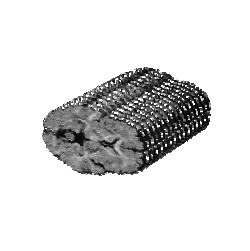

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors


# Example: list of 2D numpy arrays (grayscale images)
# Replace this with your actual image list
images = [data_norm[:,:,30, 5 + i*6] for i in range(15)]

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection="3d")

H, W = images[0].shape
x = np.arange(W)
z = np.arange(H)
X, Z = np.meshgrid(x, z)

# Normalize for colormap (keeps relative intensity)
norm = colors.Normalize(vmin=0,
                        vmax=1.)

for i, img in enumerate(images):
    Y = np.full_like(X, i)

    img_n = norm(img)                       # 0..1 for colormap
    rgba = plt.cm.gray(img_n)               # (H, W, 4)
    rgba[..., 3] = (img != 0).astype(float) # alpha: 0 where pixel==0 else 1

    ax.plot_surface(
        X, Y, Z,
        rstride=1, cstride=1,
        facecolors=rgba,
        shade=False,
        linewidth=0,
        antialiased=False,
    )



# ---- remove axes ----
ax.set_axis_off()
ax.view_init(elev=20, azim=-60)
# ---- remove axes completely ----
ax.set_axis_off()

#plt.savefig("dmri_illustrative.svg", dpi=300)


In [14]:
color1 = "#2596be"
color2 = "#be4d25"

In [15]:
ms = jnp.array([[True, True, False, False, True],
                [True, True, True, True, True]]
               )

In [16]:
m1 = ms[0]
m2 = ms[1]

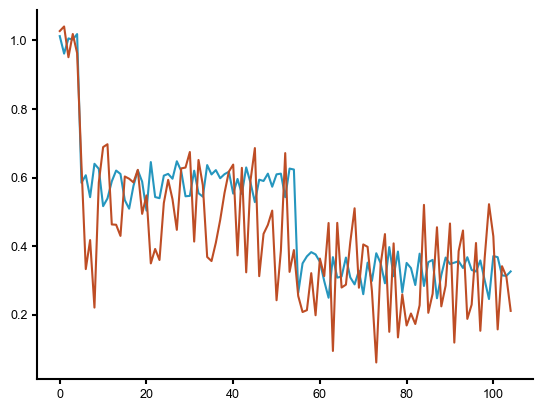

In [17]:
x_0 = full_data_flat_in_brain[10_173]
x_1 = full_data_flat_in_brain[50_000]
plt.plot(x_0, color=color1)
plt.plot(x_1, color=color2)

In [ ]:
from functools import partial
sample_fn1 = jax.jit(jax.vmap(partial(model.sample_theta, last_euler_step=False,t_min=5e-4,num_steps=64, model_mask=m2), in_axes=(0,None, None)))
sample_fn2 = jax.jit(jax.vmap(partial(model.sample_theta, t_min=5e-4,num_steps=64, model_mask=m1), in_axes=(0,None, None)))

In [10]:
thetas_post1 = sample_fn1(jax.random.split(jax.random.key(0), 200_000), acq, x_0)
thetas_post2 = sample_fn1(jax.random.split(jax.random.key(0), 200_000), acq, x_1)

In [11]:
thetas_post1_m1 = sample_fn2(jax.random.split(jax.random.key(0), 200_000), acq, x_0)
thetas_post2_m1 = sample_fn2(jax.random.split(jax.random.key(0), 200_000), acq, x_1)

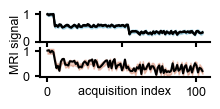

In [12]:
def pred(theta,rng,m):
    sim = sim_type.from_theta(theta, model_mask=m)
    return sim.signal(acq, rng)

xs_pred1 = jax.vmap(partial(pred, m=m2))(thetas_post1, jax.random.split(jax.random.key(1), thetas_post1.shape[0]))
xs_pred2 = jax.vmap(partial(pred, m=m2))(thetas_post2, jax.random.split(jax.random.key(1), thetas_post2.shape[0]))

xs_pred1_m1 = jax.vmap(partial(pred, m=m1))(thetas_post1_m1, jax.random.split(jax.random.key(1), thetas_post1_m1.shape[0]))
xs_pred2_m1 = jax.vmap(partial(pred, m=m1))(thetas_post2_m1, jax.random.split(jax.random.key(1), thetas_post2_m1.shape[0]))

mean1 = jnp.mean(xs_pred1, axis=0)
q99 = jnp.percentile(xs_pred1, 99, axis=0)
q01 = jnp.percentile(xs_pred1, 1, axis=0)

mean_2 = jnp.mean(xs_pred1_m1, axis=0)
q99_2 = jnp.percentile(xs_pred1_m1, 99, axis=0)
q01_2 = jnp.percentile(xs_pred1_m1, 1, axis=0)

fig , axes = plt.subplots(2,1, figsize=(2.2,0.85))

mean2 = jnp.mean(xs_pred2, axis=0)
q99_2 = jnp.percentile(xs_pred2, 99, axis=0)
q01_2 = jnp.percentile(xs_pred2, 1, axis=0)

axes[0].plot(x_0, label="Predicted mean (m2)", color="black")
axes[0].plot(mean1, label="Predicted mean (m2)", color="black")
axes[0].fill_between(np.arange(len(mean1)), q01, q99, color=color1, alpha=0.3, label="98% credible interval (m2)")

axes[1].plot(x_1, label="Predicted mean (m1)", color="black")
axes[1].fill_between(np.arange(len(mean1)), q01_2, q99_2, color=color2, alpha=0.3, label="98% credible interval (m1)")
axes[1].set_xlabel("acquisition index", labelpad=-10)
axes[0].set_yticks([0., 1.])
axes[1].set_yticks([0., 1.])
axes[1].set_xticks([0., 100.])
axes[0].set_xticklabels([])
fig.text(-0.01, 0.5, 'MRI signal', va='center', rotation='vertical')
fig.savefig("dmri_illustrative_predictions.svg", dpi=300, bbox_inches='tight', transparent=True)

In [13]:
mean1_x2 = jnp.mean(xs_pred1_m1, axis=0)
q99_x2 = jnp.percentile(xs_pred1_m1, 99, axis=0)
q01_x2 = jnp.percentile(xs_pred1_m1, 1, axis=0)

mean_2_x2 = jnp.mean(xs_pred2_m1, axis=0)
q99_2_x2 = jnp.percentile(xs_pred2_m1, 99, axis=0)
q01_2_x2 = jnp.percentile(xs_pred2_m1, 1, axis=0)

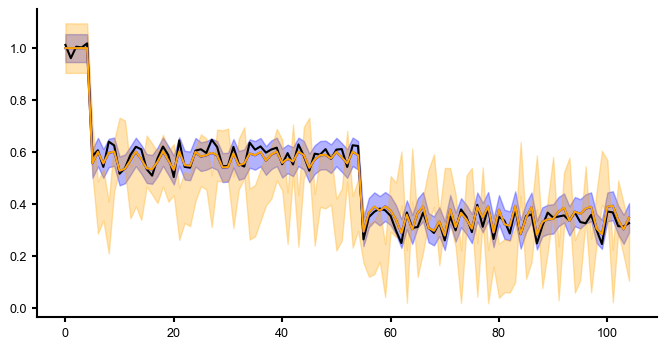

In [14]:
plt.figure(figsize=(8,4))
plt.plot(x_0, label="Observed data", color="black")
plt.plot(mean1, label="Predicted mean", color="blue")
plt.fill_between(np.arange(len(mean1)), q01, q99, color="blue", alpha=0.3, label="98% credible interval")

plt.plot(mean_2, label="Predicted mean", color="orange")
plt.fill_between(np.arange(len(mean_2)), q01_2, q99_2, color="orange", alpha=0.3, label="98% credible interval")

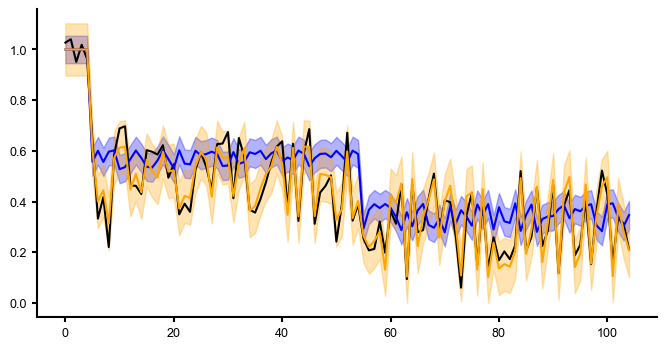

In [15]:
plt.figure(figsize=(8,4))
plt.plot(x_1, label="Observed data", color="black")
plt.plot(mean1_x2, label="Predicted mean", color="blue")
plt.fill_between(np.arange(len(mean1_x2)), q01_x2, q99_x2, color="blue", alpha=0.3, label="98% credible interval")

plt.plot(mean_2_x2, label="Predicted mean", color="orange")
plt.fill_between(np.arange(len(mean_2_x2)), q01_2_x2, q99_2_x2, color="orange", alpha=0.3, label="98% credible interval")

In [16]:
theta_mask = sim_type.theta_mask(m2)

/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


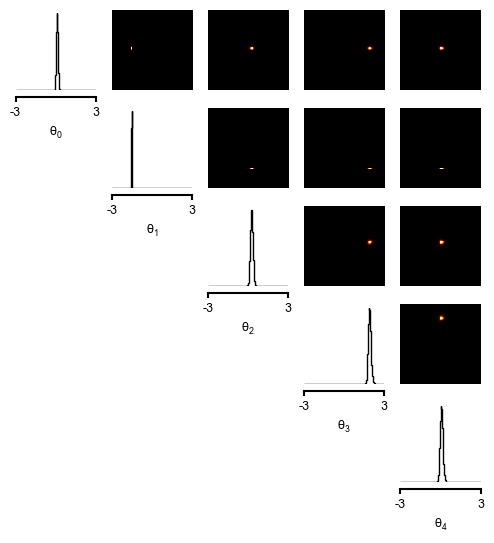

In [17]:
#import sbi
from sbi.analysis.plot import pairplot

fig, axes = pairplot([thetas_post1_m1[:,sim_type.theta_mask(m1)]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[rf'$\theta_{{{i}}}$'  for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="afmhot", origin="lower", aspect="auto"),np_hist_kwargs ={"bins": 100, "density": False},)],upper="hist", diag_kwargs=[dict(mpl_kwargs=dict(color="black", bins=200 ))])
for i in range(len(axes)):
    axes[i,i].set_xticks([-3,3])

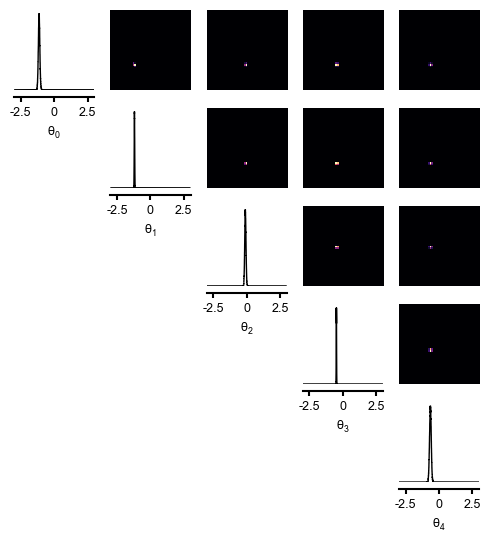

In [18]:
#import sbi
from sbi.analysis.plot import pairplot

_ = pairplot([thetas_post2_m1[:,sim_type.theta_mask(m1)]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[f'$\\theta_{i}$' for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="black"))])

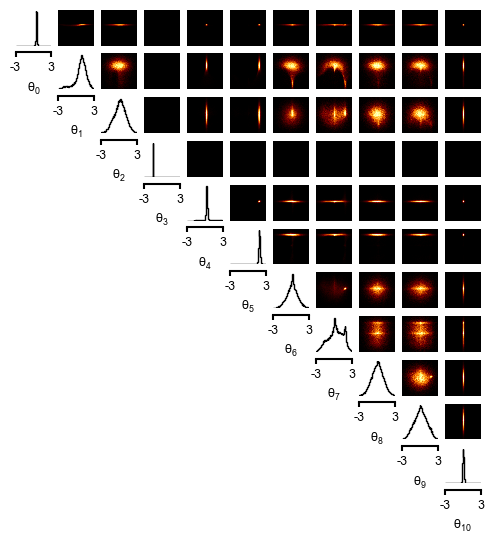

In [22]:
#import sbi
from sbi.analysis.plot import pairplot, marginal_plot

fig, axes = pairplot([thetas_post1[:,theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[rf'$\theta_{{{i}}}$'  for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="afmhot", origin="lower", aspect="auto"),np_hist_kwargs ={"bins": 100, "density": False},)],upper="hist", diag_kwargs=[dict(mpl_kwargs=dict(color="black", bins=200 ))])
for i in range(len(axes)):
    axes[i,i].set_xticks([-3,3])
fig.savefig("dmri_illustrative_pairplot_m1.svg", dpi=300, bbox_inches='tight', transparent=True)

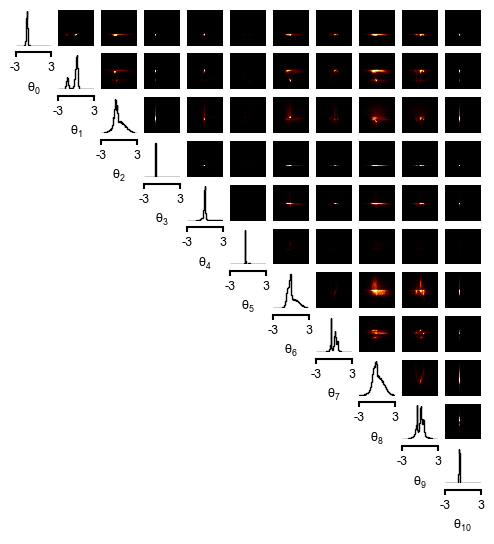

In [23]:
#import sbi
from sbi.analysis.plot import pairplot, marginal_plot

fig, axes = pairplot([thetas_post2[:,theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[rf'$\theta_{{{i}}}$'  for i in range(int(sum(theta_mask)))], figsize=(6, 6), upper_kwargs=[dict(mpl_kwargs=dict(cmap="afmhot", origin="lower", aspect="auto"),np_hist_kwargs ={"bins": 100, "density": False},)],upper="hist", diag_kwargs=[dict(mpl_kwargs=dict(color="black", bins=200 ))])
for i in range(len(axes)):
    axes[i,i].set_xticks([-3,3])
fig.savefig("dmri_illustrative_pairplot_m2.svg", dpi=300, bbox_inches='tight', transparent=True)

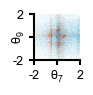

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def transparent_cmap(color, name, n=256, gamma=1.0):
    """
    Create a colormap that goes from transparent to a given RGB/hex color.
    gamma > 1 makes low values more transparent for longer (helps overlays).
    """
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    x = np.linspace(0, 1, n)
    a = x**gamma  # alpha ramp
    rgba = np.column_stack([np.full(n, r), np.full(n, g), np.full(n, b), a])
    return LinearSegmentedColormap.from_list(name, rgba)

# Two custom overlay-friendly colormaps
cmap_post2 = transparent_cmap(color1, "post2_blue_alpha", gamma=1.2)  # blue-ish
cmap_post1 = transparent_cmap(color2, "post1_orange_alpha", gamma=.6)  # orange-ish

twod_marg = thetas_post1[:, [7,9]]
twod_marg2 = thetas_post2[:, [7,9]]
fig = plt.figure(figsize=(.6,0.6))
# Your plotting (unchanged except cmap=...)

_ = plt.hist2d(
    x=twod_marg[:, 0], y=twod_marg[:, 1],
    bins=100, density=True,
    range=[[-2, 2], [-2, 2]],
    cmap=cmap_post2,
    rasterized=True
)

_ = plt.hist2d(
    x=twod_marg2[:, 0], y=twod_marg2[:, 1],
    bins=100, density=True,
    range=[[-2, 2], [-2, 2]],
    cmap=cmap_post1,
    rasterized=True
)


plt.xlim(-2, 2); plt.ylim(-2, 2)
plt.xticks([-2., 0., 2.], ["-2", "", "2"])
plt.yticks([-2., 0., 2.], ["-2", "", "2"])
plt.xlabel(r'$\theta_{7}$', labelpad=-10)
plt.ylabel(r'$\theta_{9}$', labelpad=-10)
plt.show()
fig.savefig("dmri_illustrative_marginal2d.svg", dpi=300, bbox_inches='tight', transparent=True)


/tmp/ipykernel_2833985/534213694.py:1: DeprecationWarning: **kwargs are deprecated, use fig_kwargs instead. calling the to be deprecated marginal_plot function
  fig, axes = marginal_plot([thetas_post2, thetas_post1], subset=[0,1,6,7], limits=[[-3,3]]*int(sum(theta_mask)), labels=[f'$\\theta_{i}$' for i in range(int(sum(theta_mask)))], figsize=(2.75, 0.5), colors=[color2, color1],diag='hist', diag_kwargs=[dict(bins=300)])


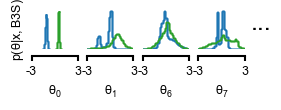

In [ ]:
fig, axes = marginal_plot([thetas_post2, thetas_post1], subset=[0,1,6,7], limits=[[-3,3]]*int(sum(theta_mask)), labels=[f'$\\theta_{i}$' for i in range(int(sum(theta_mask)))], figsize=(2.75, 0.5), colors=[color2, color1],diag='hist', diag_kwargs=[dict(bins=300)])
axes[0,0].set_ylabel(r"$p(\theta | x, B3S)$")
for ax in axes.flatten():
    ax.set_xticks([-3,3])
fig.savefig("dmri_illustrative_marginals.svg", dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
@jax.jit(static_argnames=['num_samples'])
def estimate_marginal_likelihood(rng,model_mask, data, num_samples=512):
    mu, _ = model.estimate_evidence(rng, acq=data["acq"], x=data['x'], model_mask=model_mask, num_samples=num_samples, estimator='importance', defensive_eps=0.0, num_steps=1024)
    return mu

In [ ]:
data_single1 = {"acq": acq,
"x": x_0, "model_mask": m2}

data_single2 = {"acq": acq,
"x": x_1, "model_mask": m2}

In [ ]:
mask_support = jnp.array([[True, True, False, False, True],
                          [True, True, True, False, True],
                          [True, True, True, True, True]])

In [ ]:
evidences = []
# MC samples
for i in range(10):
    evidences_support = [estimate_marginal_likelihood(jax.random.key(1000*i+j), mask_support[j], data_single1) for j in range(len(mask_support))]
    evidences.append(evidences_support)

In [ ]:
evidences2 = []
# MC samples
for i in range(10):
    evidences_support = [estimate_marginal_likelihood(jax.random.key(1000*i+j), mask_support[j], data_single2) for j in range(len(mask_support))]
    evidences2.append(evidences_support)

In [ ]:
model_ll = jnp.array(evidences)
model_prior = jax.vmap(mask_prior.log_prob, in_axes=(0, None))(mask_support, jnp.array([0.3]))
model_posterior_unnorm = model_ll + model_prior[None, :]
model_posterior = jax.nn.softmax(model_posterior_unnorm , axis=-1)

In [ ]:
model_ll2 = jnp.array(evidences2)
model_prior2 = jax.vmap(mask_prior.log_prob, in_axes=(0, None))(mask_support, jnp.array([0.3]))
model_posterior_unnorm2 = model_ll2 + model_prior2[None, :]
model_posterior2 = jax.nn.softmax(model_posterior_unnorm2 , axis=-1)

In [ ]:
approx_model_posterior = jax.vmap(model.log_prob_mask, in_axes=(0, None, None,None))(mask_support, data_single1["acq"], data_single1["x"], 0.3)
approx_model_posterior = jax.nn.softmax(approx_model_posterior)

In [ ]:
approx_model_posterior2 = jax.vmap(model.log_prob_mask, in_axes=(0, None, None,None))(mask_support, data_single2["acq"], data_single2["x"], 0.3)
approx_model_posterior2 = jax.nn.softmax(approx_model_posterior2, axis=-1)

In [ ]:
model_posterior_mean = jnp.mean(model_posterior, axis=0)
model_posterior_q025 = jnp.percentile(model_posterior, 2.5, axis=0)
model_posterior_q975 = jnp.percentile(model_posterior, 97.5, axis=0)

In [ ]:
model_posterior_mean2 = jnp.mean(model_posterior2, axis=0)
model_posterior_q0252 = jnp.percentile(model_posterior2, 2.5, axis=0)
model_posterior_q9752 = jnp.percentile(model_posterior2, 97.5, axis=0)

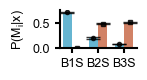

In [ ]:
plt.figure(figsize=(1., 0.5))

# Calculate error bar magnitudes for both posteriors
error_lower = jnp.maximum(0, model_posterior_mean - model_posterior_q025)
error_upper = jnp.maximum(0, model_posterior_q975 - model_posterior_mean)

error_lower2 = jnp.maximum(0, model_posterior_mean2 - model_posterior_q0252)
error_upper2 = jnp.maximum(0, model_posterior_q9752 - model_posterior_mean2)

# Create x positions for bars
x_pos = np.arange(len(model_posterior_mean))
width = 0.35

# Plot approximate posteriors as bars
plt.bar(x_pos - width/2, approx_model_posterior, width, color=color1,
    alpha=0.7, label='Approximate posterior (voxel 1)')

plt.bar(x_pos + width/2, approx_model_posterior2, width, color=color2,
    alpha=0.7, label='Approximate posterior (voxel 2)')

# Plot MC approximation (true posteriors) as lines with error bars
plt.errorbar(x_pos- 0.2, model_posterior_mean,
    yerr=[error_lower, error_upper],
    fmt='o', color="black", alpha=0.8, label='True posterior (voxel 1)', capsize=5)

l = plt.errorbar(x_pos+ 0.2, model_posterior_mean2,
    yerr=[error_lower2, error_upper2],
    fmt='s', color='black', alpha=0.8, label='True posterior (voxel 2)', capsize=5)

plt.xticks(x_pos, ["B1S", "B2S", "B3S"])
plt.ylabel("$P(M_i | x)$")
#plt.title("Model selection posterior")
#plt.legend(handles=[l], loc='upper left')
plt.xticks(x_pos)
plt.savefig("dmri_model_selection.svg", dpi=300)


In [ ]:
# Evalute MC of ground truth for various voxels
b3s_support = jnp.array([[True, True, False, False, True],
                    [True, True, True, False, True],
                    [True, True, True, True, True]])
def evidence_model_posterior(rng, data, num_samples=512):
    sample_fn = lambda rng, model_mask: model.estimate_evidence(rng, acq=data["acq"], x=data['x'], model_mask=model_mask, num_samples=num_samples, estimator='importance', defensive_eps=0.0, num_steps=256)[0]
    rngs = jax.random.split(rng, b3s_support.shape[0])
    mu = jax.vmap(sample_fn)(rngs, b3s_support)
    return mu

In [ ]:
xs_subset = jax.random.choice(jax.random.key(0), full_data_flat_in_brain, shape=(500,), replace=False, axis=0)
acq_rep = jax.tree_util.tree_map(lambda x: jnp.repeat(x[None, :], 500, axis=0), acq)
data_evidence = {"acq": acq_rep,
"x": xs_subset}
rngs = jax.random.split(jax.random.key(213123), 500)

In [ ]:
estimator_fn = jax.jit(lambda rng: jax.lax.map(lambda x: evidence_model_posterior(x[0],x[1]), (jax.random.split(rng, (500,)), data_evidence), batch_size=10))

In [ ]:
evidences_eval = estimator_fn(jax.random.key(0))

In [ ]:
evidences_eval2 = estimator_fn(jax.random.key(1))

In [ ]:
jnp.savez("dmri_illustrative_evidences.npz", evidences_eval=evidences_eval, evidences_eval2=evidences_eval2)

In [ ]:
mask_prior = sim_type.create_mask_prior()

In [ ]:
def q_evidence(data):
    log_prob_fn = lambda model_mask: model.log_prob_mask(model_mask, data["acq"], data["x"], 0.3)
    log_probs = jax.vmap(log_prob_fn)(b3s_support)
    prior_probs = jax.vmap(mask_prior.log_prob, in_axes=(0, None))(b3s_support, jnp.array([0.3]))
    evidences = log_probs - prior_probs
    return evidences

approx_evidences = jax.vmap(q_evidence)(data_evidence)


In [ ]:
estimated_evidences_normed2 = jax.nn.softmax(evidences_eval2 , axis=-1)

In [ ]:
estimated_evidences_normed = jax.nn.softmax(evidences_eval , axis=-1)

In [ ]:
approx_evidences_normed = jax.nn.softmax(approx_evidences , axis=-1)

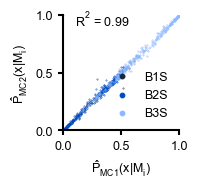

In [ ]:
fig = plt.figure(figsize=(1.5,1.5))
ax = fig.add_subplot(111)
plt.scatter(estimated_evidences_normed[:,0], estimated_evidences_normed2[:,0], color="#162741", s=0.1, label="B1S")
plt.scatter(estimated_evidences_normed[:,1], estimated_evidences_normed2[:,1], color="#004CC3", s=0.1, label="B2S")
plt.scatter(estimated_evidences_normed[:,2], estimated_evidences_normed2[:,2 ], color="#8EB9FF", s=0.1, label="B3S")
r2 = r2_score(estimated_evidences_normed, estimated_evidences_normed2)
plt.xlabel(r"$\hat{P}_{MC1}(x | M_i)$")
plt.ylabel(r"$\hat{P}_{MC2}(x| M_i)$")
plt.ylim(0,1)
plt.xlim(0,1)
plt.xticks([0., 0.5, 1.])
plt.yticks([0., 0.5, 1.])
plt.text(0.1, 0.9, f"$R^2$ = {r2:.2f}", transform=ax.transAxes)
plt.legend(markerscale=10, loc='lower right')
plt.savefig("dmri_illustrative_evidence_correlation.svg", dpi=300, bbox_inches='tight', transparent=True)

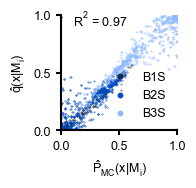

In [ ]:
fig = plt.figure(figsize=(1.5,1.5))
ax = fig.add_subplot(111)
plt.scatter(estimated_evidences_normed[:,0], approx_evidences_normed[:,0], color="#162741", s=0.1, label="B1S")
plt.scatter(estimated_evidences_normed[:,1], approx_evidences_normed[:,1], color="#004CC3", s=0.1, label="B2S")
plt.scatter(estimated_evidences_normed[:,2], approx_evidences_normed[:,2 ], color="#8EB9FF", s=0.1, label="B3S")
plt.scatter(estimated_evidences_normed2[:,0], approx_evidences_normed[:,0], color="#162741", s=0.1)
plt.scatter(estimated_evidences_normed2[:,1], approx_evidences_normed[:,1], color="#004CC3", s=0.1)
plt.scatter(estimated_evidences_normed2[:,2], approx_evidences_normed[:,2 ], color="#8EB9FF", s=0.1)
r2 = r2_score(estimated_evidences_normed, approx_evidences_normed) / 2 + r2_score(estimated_evidences_normed2, approx_evidences_normed) / 2
plt.xlabel(r"$\hat{P}_{MC}(x | M_i)$")
plt.ylabel(r"$\hat{q}(x | M_i)$")
plt.ylim(0,1)
plt.xlim(0,1)
plt.xticks([0., 0.5, 1.])
plt.yticks([0., 0.5, 1.])
plt.text(0.1, 0.9, f"$R^2$ = {r2:.2f}", transform=ax.transAxes)
plt.legend(markerscale=10, loc='lower right')
plt.savefig("dmri_illustrative_evidence_correlation_approx.svg", dpi=300, bbox_inches='tight', transparent=True)

In [ ]:

def true_posterior(lam):
    prior_fn = lambda model_mask: mask_prior.log_prob(model_mask, jnp.array([lam]))
    log_prior = jax.vmap(prior_fn)(b3s_support)
    log_posterior = evidences_eval + log_prior[None, :]
    return jax.nn.softmax(log_posterior , axis=-1)
def true_posterior2(lam):
    prior_fn = lambda model_mask: mask_prior.log_prob(model_mask, jnp.array([lam]))
    log_prior = jax.vmap(prior_fn)(b3s_support)
    log_posterior = evidences_eval2 + log_prior[None, :]
    return jax.nn.softmax(log_posterior , axis=-1)

def approx_posterior(lam):
    log_posterior_fn = lambda model_mask, x: model.log_prob_mask(model_mask, x["acq"], x["x"], lam)
    log_posterior = jax.vmap(jax.vmap(log_posterior_fn, in_axes=(0, None)), in_axes=(None, 0))(b3s_support, data_evidence)
    return jax.nn.softmax(log_posterior , axis=-1)


In [ ]:
lams = jnp.linspace(0.01, 1.0, 50)
true_posteriors1 = jax.vmap(true_posterior)(lams)
true_posteriors2 = jax.vmap(true_posterior2)(lams)

In [ ]:
approx_posteriors = jax.vmap(approx_posterior)(lams)

In [ ]:
l1_dist = jnp.mean(jnp.abs(true_posteriors1 - approx_posteriors), axis=-1)
l1_dist

Array([[4.48605698e-03, 2.40457850e-03, 8.61822069e-03, ...,
        6.18802726e-01, 2.20598668e-01, 1.06866863e-02],
       [1.44368736e-02, 6.88834256e-03, 1.12084318e-02, ...,
        2.97882169e-01, 3.12468797e-01, 3.75870988e-02],
       [1.55040920e-02, 1.03835985e-02, 1.44930631e-02, ...,
        1.96167991e-01, 3.02199900e-01, 4.54922989e-02],
       ...,
       [2.71708285e-03, 5.38530340e-03, 6.52343035e-04, ...,
        1.15796784e-03, 2.90303398e-03, 1.85075705e-03],
       [1.46747567e-03, 2.72595650e-03, 4.76117246e-04, ...,
        5.28664677e-04, 1.38332602e-03, 4.54679219e-04],
       [2.68539239e-04, 4.45618236e-04, 1.44321399e-04, ...,
        2.62953145e-05, 2.31231352e-05, 2.01584044e-04]], dtype=float32)

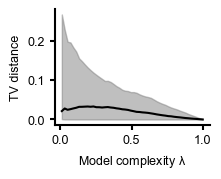

In [ ]:
tv = 0.5 * jnp.abs(true_posteriors1 - approx_posteriors).sum(-1)
tv_true2 = jnp.median(0.5 * jnp.abs(true_posteriors2 - true_posteriors1).sum(-1), axis=1)
tv_q025 = jnp.percentile(tv, 15, axis=1)
tv_q975 = jnp.percentile(tv, 85, axis=1)
median_tv = jnp.median(tv, axis=1)
fig = plt.figure(figsize=(2,1.5))
plt.plot(lams,median_tv, color="black")
plt.fill_between(lams, tv_q025, tv_q975, color="gray", alpha=0.5)
plt.ylabel("TV distance")
plt.xlabel(r"Model complexity $\lambda$")
plt.savefig("dmri_illustrative_tv_distance.svg", dpi=300, bbox_inches='tight', transparent=True)

In [24]:
masks_ball = jnp.array([[True, False, False, False, True]])
masks_bs1 = jnp.array([[True, True, False, False, True],
                       [True, False, True, False, True],
                       [True, False, False, True, True]])
masks_bs2 = jnp.array([[True, True, True, False, True],
                       [True, True, False, True, True],
                       [True, False, True, True, True]])
masks_b3s = jnp.array([[True, True, True, True, True]])

In [28]:
@jax.jit
def log_prob_mask_batch(data, lam=0.1):
    log_prob_fn = lambda model_mask: model.log_prob_mask(model_mask, acq, data, lam)
    log_probs_ball = jax.vmap(log_prob_fn)(masks_ball)
    log_probs_bs1 = jax.vmap(log_prob_fn)(masks_bs1)
    log_probs_bs2 = jax.vmap(log_prob_fn)(masks_bs2)
    log_probs_b3s = jax.vmap(log_prob_fn)(masks_b3s)
    log_probs_ball = jax.scipy.special.logsumexp(log_probs_ball)
    log_probs_bs1 = jax.scipy.special.logsumexp(log_probs_bs1)
    log_probs_bs2 = jax.scipy.special.logsumexp(log_probs_bs2)
    log_probs_b3s = jax.scipy.special.logsumexp(log_probs_b3s)
    log_probs = jnp.array([log_probs_ball, log_probs_bs1, log_probs_bs2, log_probs_b3s])
    return log_probs

In [26]:
batch_size = 20_000
key = jax.random.key(0)
probs_brain_01 = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = jax.vmap(partial(log_prob_mask_batch, lam=0.1))(batch_data)
    batch_masks = np.array(batch_masks)
    probs_brain_01.append(batch_masks)
probs_brain_01 = np.concatenate(probs_brain_01, axis=0)

Batch 0
Batch 20000
Batch 40000
Batch 60000
Batch 80000
Batch 100000
Batch 120000
Batch 140000
Batch 160000
Batch 180000
Batch 200000
Batch 220000


In [29]:
batch_size = 20_000
key = jax.random.key(0)
probs_brain_02 = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = jax.vmap(partial(log_prob_mask_batch, lam=0.2))(batch_data)
    batch_masks = np.array(batch_masks)
    probs_brain_02.append(batch_masks)
probs_brain_02 = np.concatenate(probs_brain_02, axis=0)

Batch 0
Batch 20000
Batch 40000
Batch 60000
Batch 80000
Batch 100000
Batch 120000
Batch 140000
Batch 160000
Batch 180000
Batch 200000
Batch 220000


In [102]:
batch_size = 20_000
key = jax.random.key(0)
probs_brain_03= []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = jax.vmap(partial(log_prob_mask_batch, lam=0.3))(batch_data)
    batch_masks = np.array(batch_masks)
    probs_brain_03.append(batch_masks)
probs_brain_03 = np.concatenate(probs_brain_03, axis=0)

Batch 0
Batch 20000
Batch 40000
Batch 60000
Batch 80000
Batch 100000
Batch 120000
Batch 140000
Batch 160000
Batch 180000
Batch 200000
Batch 220000


In [32]:
marginal_probs_01 = jax.nn.softmax(probs_brain_01 , axis=-1)
full_brain_marginal_probs_01 = np.zeros((brain_mask_flat.shape[0], marginal_probs_01.shape[1]))
full_brain_marginal_probs_01[brain_mask_flat.astype(np.bool),:] = marginal_probs_01
full_brain_marginal_probs_01 = full_brain_marginal_probs_01.reshape(brain_mask.shape + (marginal_probs_01.shape[1],))

In [33]:
marginal_probs_02 = jax.nn.softmax(probs_brain_02, axis=-1)
full_brain_marginal_probs_02 = np.zeros((full_data_flat.shape[0], 4))
full_brain_marginal_probs_02[brain_mask_flat.astype(np.bool),...] = marginal_probs_02
full_brain_marginal_probs_02 = full_brain_marginal_probs_02.reshape(data_norm.shape[:-1] + (4,))

In [103]:
marginal_probs_03 = jax.nn.softmax(probs_brain_03, axis=-1)
full_brain_marginal_probs_03 = np.zeros((full_data_flat.shape[0], 4))
full_brain_marginal_probs_03[brain_mask_flat.astype(np.bool),...] = marginal_probs_03
full_brain_marginal_probs_03 = full_brain_marginal_probs_03.reshape(data_norm.shape[:-1] + (4,))

In [104]:
slice1_axial = full_brain_marginal_probs_01[:, :, 35, :]
slice2_cortical = full_brain_marginal_probs_01[:, 52, :, :]

In [105]:
slice1_axial_2 = full_brain_marginal_probs_03[:, :, 35, :]
slice2_cortical_2 = full_brain_marginal_probs_03[:, 52, :, :]

In [106]:
full_brain_marginal_probs_03.shape

(104, 104, 72, 4)

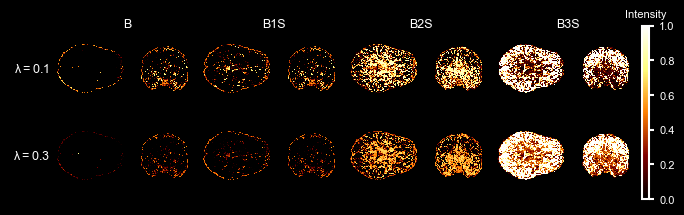

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = "afmhot"
vmin, vmax = 0.0, 1.0

# Layout: 2 rows, 9 content columns (1 label + 8 images), plus 1 colorbar column = 10 total
fig = plt.figure(figsize=(8.25, 2.25), facecolor="black")
gs = fig.add_gridspec(
    nrows=2, ncols=10,
    width_ratios=[0.60, 1, 1, 1, 1, 1, 1, 1, 1, 0.10],  # [row label | 8 panels | cbar]
    wspace=0.02, hspace=0.02
)

# Axes for 2 x (1 label + 8 panels)  -> 2 x 9
axes = np.empty((2, 9), dtype=object)
for i in range(2):
    for j in range(9):
        ax = fig.add_subplot(gs[i, j])
        ax.set_facecolor("black")
        ax.axis("off")
        axes[i, j] = ax

# ---- Images (columns 1..8) ----
# top row
im = axes[0, 1].imshow(slice1_axial[..., 0], cmap=cmap, origin="lower",
                       vmin=vmin, vmax=vmax, interpolation="nearest")
axes[0, 2].imshow(slice2_cortical[..., 1].T, cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[0, 3].imshow(slice1_axial[..., 1], cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[0, 4].imshow(slice2_cortical[..., 1].T, cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[0, 5].imshow(slice1_axial[..., 2], cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[0, 6].imshow(slice2_cortical[..., 2].T, cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[0, 7].imshow(slice1_axial[..., 3], cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[0, 8].imshow(slice2_cortical[..., 3].T, cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")

# bottom row
axes[1, 1].imshow(slice1_axial_2[..., 0], cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[1, 2].imshow(slice2_cortical_2[..., 1].T, cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[1, 3].imshow(slice1_axial_2[..., 1], cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[1, 4].imshow(slice2_cortical_2[..., 1].T, cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[1, 5].imshow(slice1_axial_2[..., 2], cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[1, 6].imshow(slice2_cortical_2[..., 2].T, cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[1, 7].imshow(slice1_axial_2[..., 3], cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
axes[1, 8].imshow(slice2_cortical_2[..., 3].T, cmap=cmap, origin="lower",
                  vmin=vmin, vmax=vmax, interpolation="nearest")

# ---- Row labels (left-most column 0) ----
axes[0, 0].text(0.5, 0.5, r"$\lambda=0.1$", color="white",
                ha="center", va="center", fontsize=9, transform=axes[0, 0].transAxes)
axes[1, 0].text(0.5, 0.5, r"$\lambda=0.3$", color="white",
                ha="center", va="center", fontsize=9, transform=axes[1, 0].transAxes)

# ---- Column group labels across the top row (spanning pairs of panels) ----
# Pairs: (1,2)->B ; (3,4)->B1S ; (5,6)->B2S ; (7,8)->B3S
pair_labels = [("B", (1, 2)), ("B1S", (3, 4)), ("B2S", (5, 6)), ("B3S", (7, 8))]
for label, (c1, c2) in pair_labels:
    p1 = axes[0, c1].get_position()
    p2 = axes[0, c2].get_position()
    x_center = 0.5 * (p1.x0 + p2.x1)
    y_top = max(p1.y1, p2.y1) + 0.01
    fig.text(x_center, y_top, label, color="white",
             ha="center", va="bottom", fontsize=9)

# ---- Single shared colorbar (last column 9, spans both rows) ----
cax = fig.add_subplot(gs[:, 9])
cax.set_facecolor("black")
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax)
cb.outline.set_edgecolor("white")
cb.ax.tick_params(colors="white", labelsize=8)
for spine in cb.ax.spines.values():
    spine.set_edgecolor("white")
cb.ax.set_title("Intensity", color="white", fontsize=8, pad=6)

plt.show()
fig.savefig("dmri_illustrative_model_posteriors_brain.svg", dpi=300, bbox_inches='tight', transparent=False)


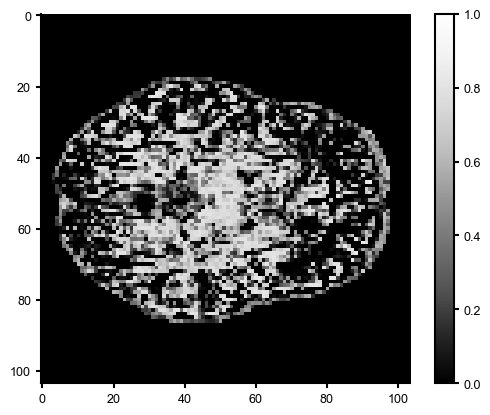

In [70]:
plt.imshow(full_brain_marginal_probs_02[:,:,32,2], vmin=0., vmax=1., cmap='Greys_r')
plt.colorbar()

In [35]:
xs_subset = jax.random.choice(jax.random.key(0), full_data_flat_in_brain, shape=(1000,), replace=False, axis=0)

In [25]:
from functools import partial
@partial(jax.jit, static_argnames=['num_steps'])
def sample_fn_num_steps(rng, data, num_steps):
    n_samples = 1000
    sample_fn = jax.jit(jax.vmap(partial(model.sample_theta, last_euler_step=False,t_min=5e-4,num_steps=num_steps, model_mask=m2), in_axes=(None,None, 0)))
    out = jax.vmap(sample_fn, in_axes=(0,None,None))(jax.random.split(rng, n_samples), acq, data)
    return out

@jax.jit
def sample_model(rng, data):
    n_samples = 1000
    sample_fn = jax.jit(jax.vmap(partial(model.sample_mask, mask_prior=0.5), in_axes=(None,None, 0)))
    out = jax.vmap(sample_fn, in_axes=(0,None,None))(jax.random.split(rng, n_samples), acq, data)
    return out



@jax.jit
def eval_ess(samples, x_o):
    # Accurate log_prob for effective metric estimation
    log_q = jax.vmap(partial(model.log_prob_theta, acq=acq, x=x_o, model_mask=m2, num_steps=1024), in_axes=(0))(samples)
    def log_posterior(theta):
        sim = sim_type.from_theta(theta, model_mask=m2)
        theta_masked = sim_type.theta_mask(m2)
        log_lik = sim.log_likelihood(acq, x_o)
        log_prior = jnp.sum(jax.scipy.stats.norm.logpdf(theta) * theta_masked)
        return log_lik + log_prior

    log_p = jax.vmap(log_posterior, in_axes=(0))(samples)
    log_weights = log_p - log_q
    weights_normalized = jax.nn.softmax(log_weights)
    ess = 1.0 / jnp.sum(weights_normalized ** 2)
    return ess/1000

In [27]:
%%timeit
out = sample_fn_num_steps(jax.random.key(0), x_1[None], num_steps=32)
out.block_until_ready()

31.2 ms ± 205 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%%timeit
out = sample_model(jax.random.key(0), x_1[None])
out.block_until_ready()

3.3 ms ± 252 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


: 

In [ ]:
%%timeit

In [ ]:
import time
num_steps = [2,4,8,16,32,64,128,256,512]
ess_values = []
run_times_values = []
runs = 5
for ns in num_steps:
    ess_ns = []
    run_times_ns = []
    # Compile
    out = sample_fn_num_steps(jax.random.key(0), x_1[None], num_steps=ns)
    for r in range(runs):
        start = time.time()
        out = sample_fn_num_steps(jax.random.key(r), x_1[None], num_steps=ns)
        out.block_until_ready()
        run_time = time.time() - start
        ess = eval_ess(out[:,0], x_1)
        ess_ns.append(ess)
        run_times_ns.append(run_time)
    ess_values.append(jnp.array(ess_ns))
    run_times_values.append(jnp.array(run_times_ns))

In [163]:
import time
num_steps = [2,4,8,16,32,64,128,256,512]
run_times_values = []
runs = 10
for ns in num_steps:
    run_times_ns = []
    # Compile
    val = x_1[None]
    out = sample_fn_num_steps(jax.random.key(0), val, num_steps=ns)
    for r in range(runs):
        start = time.time()
        out = sample_fn_num_steps(jax.random.key(r), val, num_steps=ns)
        out.block_until_ready()
        run_time = time.time() - start
        run_times_ns.append(run_time)
    run_times_values.append(jnp.array(run_times_ns))

In [14]:
import time
num_steps = [2,4,8,16,32,64,128,256,512]
run_times_values = []
runs = 10
with jax.default_device(jax.devices("cpu")[0]):
    for ns in num_steps:
        run_times_ns = []
        # Compile
        val = x_1[None]
        out = sample_fn_num_steps(jax.random.key(0), val, num_steps=ns)
        for r in range(runs):
            start = time.time()
            out = sample_fn_num_steps(jax.random.key(r), val, num_steps=ns)
            out.block_until_ready()
            run_time = time.time() - start
            run_times_ns.append(run_time)
        run_times_values.append(jnp.array(run_times_ns))

Exception ignored in: <function _xla_gc_callback at 0x155533b4f4c0>
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/jax/_src/lib/__init__.py", line 124, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


ValueError: Only interpret mode is supported on CPU backend.

In [164]:
run_times_values

[Array([0.00209117, 0.00146151, 0.00142384, 0.00143433, 0.00143743,
        0.00142932, 0.00141144, 0.00139689, 0.00140095, 0.0013926 ],      dtype=float32),
 Array([0.00770712, 0.00441408, 0.00435829, 0.0043633 , 0.00436568,
        0.00433803, 0.00434518, 0.00434113, 0.0043385 , 0.00434303],      dtype=float32),
 Array([0.01517987, 0.00822639, 0.00813198, 0.00812244, 0.00815439,
        0.00815606, 0.00820851, 0.00819516, 0.00820136, 0.00820231],      dtype=float32),
 Array([0.03052974, 0.0162344 , 0.01616263, 0.01609993, 0.01606727,
        0.01607132, 0.01603937, 0.01607633, 0.01605678, 0.01605153],      dtype=float32),
 Array([0.06124997, 0.03180575, 0.03156185, 0.03190851, 0.03147125,
        0.03146267, 0.03148866, 0.0315299 , 0.03152394, 0.03154898],      dtype=float32),
 Array([0.12200594, 0.06254816, 0.06229305, 0.06239176, 0.06251931,
        0.06227303, 0.06231976, 0.06241131, 0.06230593, 0.06224465],      dtype=float32),
 Array([0.24414563, 0.12368131, 0.12370467, 0.123578

In [12]:
run_time = jnp.array(run_times_values)
ess = jnp.array(ess_values)
run_time_mean = jnp.mean(run_time, axis=1)
ess_mean = jnp.mean(ess, axis=1)
run_time_q025 = jnp.percentile(run_time, 2.5, axis=1)
run_time_q975 = jnp.percentile(run_time, 97.5, axis=1)
ess_q025 = jnp.percentile(ess, 2.5, axis=1)
ess_q975 = jnp.percentile(ess, 97.5, axis=1)
fig, ax = plt.subplots(2,figsize=(3,3))
ax[0].plot(num_steps, ess_mean, color="black")
ax[0].fill_between(num_steps, ess_q025, ess_q975, color="gray", alpha=0.5)
ax[1].plot(num_steps, 1000 * run_time_mean, color="black")
ax[1].fill_between(num_steps, 1000 * run_time_q025, 1000 * run_time_q975, color="gray", alpha=0.5)
ax[0].set_ylabel("ESS")
ax[0].set_xscale("log", base=2)
ax[0].set_xticks([2,4,8,16,32,64,128,256,512])
ax[0].set_xticklabels(["","","","","","","","",""])
ax[1].set_xscale("log", base=2)
ax[1].set_yscale("log")
ax[1].set_xticks([2,4,8,16,32,64,128,256,512])
ax[1].set_xticklabels(["2","4","8","16","32","64","128","256","512"])

ax[1].set_xlabel("Number of diffusion steps")
ax[1].set_ylabel("Run time (ms)")
fig.savefig("dmri_illustrative_ess_runtimes.svg", dpi=300, bbox_inches='tight', transparent=True)

NameError: name 'run_times_values' is not defined

In [126]:
eval_ess(out[:,0], x_1)

Array(0.5976202, dtype=float32)

In [115]:
out = sample_fn_num_steps(jax.random.key(0), x_0[None], num_steps=32)

In [116]:
eval_ess(out[:,0], x_0)

Array(0.53796333, dtype=float32)